**Name:** Priyanshi Mehta  
**Internship:** Celebal Technologies-Data Science  
**Submission Date:** 14 June 2026

# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook presents a complete clustering workflow on the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data  
- Clean and preprocess features  
- Apply StandardScaler  
- Find the optimal number of clusters using the Elbow Method  
- Train K-Means and evaluate with Silhouette Score  
- Apply DBSCAN as a secondary clustering method  
- Visualize clusters using PCA  
- Generate socio-economic insights per cluster

## 1) Install Required Libraries

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import Libraries

In [2]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
print("Libraries imported successfully.")

Libraries imported successfully.


## 3) Load the Dataset

> **Instructions:** Run this cell. Ek popup aayega — usme apni `Country-data.csv` file select karo. File automatically load ho jayegi.

In [3]:
# ✅ Colab-compatible CSV upload — popup aayega, usme Country-data.csv select karo
from google.colab import files
import io

print("CSV file upload karo (Country-data.csv):")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

CSV file upload karo (Country-data.csv):


Saving Country-data.csv to Country-data.csv

✅ Dataset loaded: 167 rows × 10 columns


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick Inspection

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())
display(df.describe(include='all').T)

Shape: (167, 10)

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Basic Cleaning

Strip whitespace from column names, drop duplicates, force numeric types, and impute missing values with the median.

In [5]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Missing values after cleaning:")
print(df.isna().sum())
print(f"\nFinal shape: {df.shape}")

Missing values after cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Final shape: (167, 10)


## 6) Exploratory Data Analysis

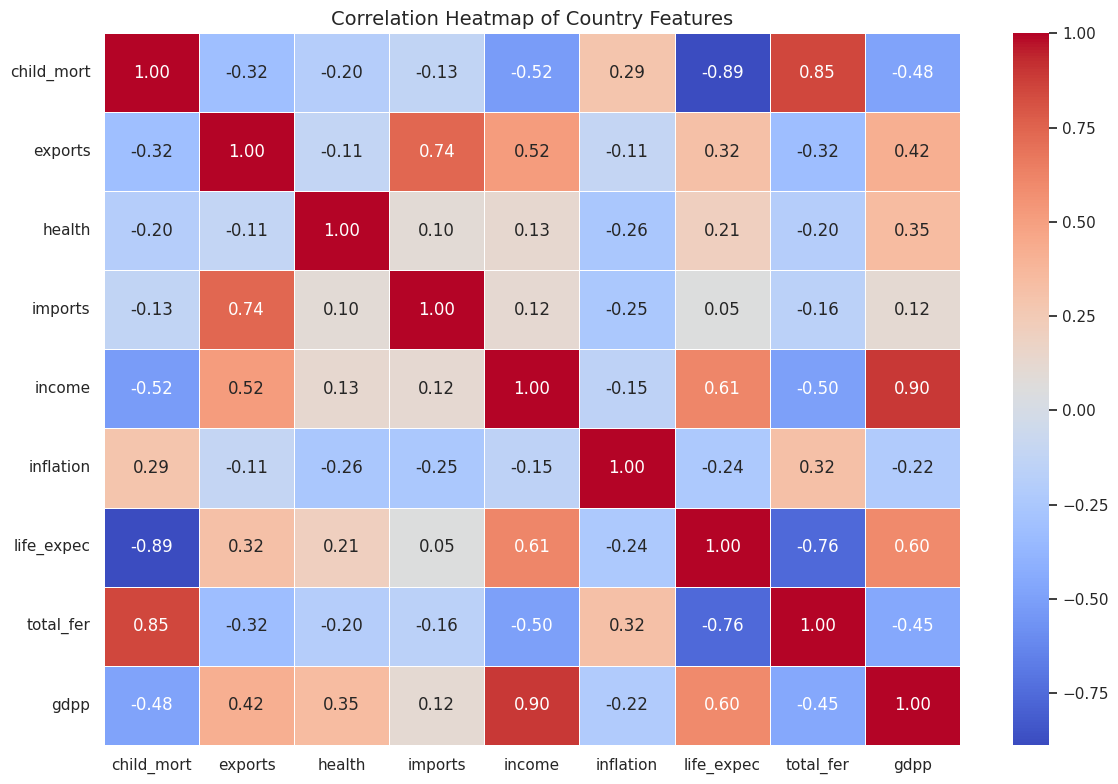

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Country Features', fontsize=14)
plt.tight_layout()
plt.show()

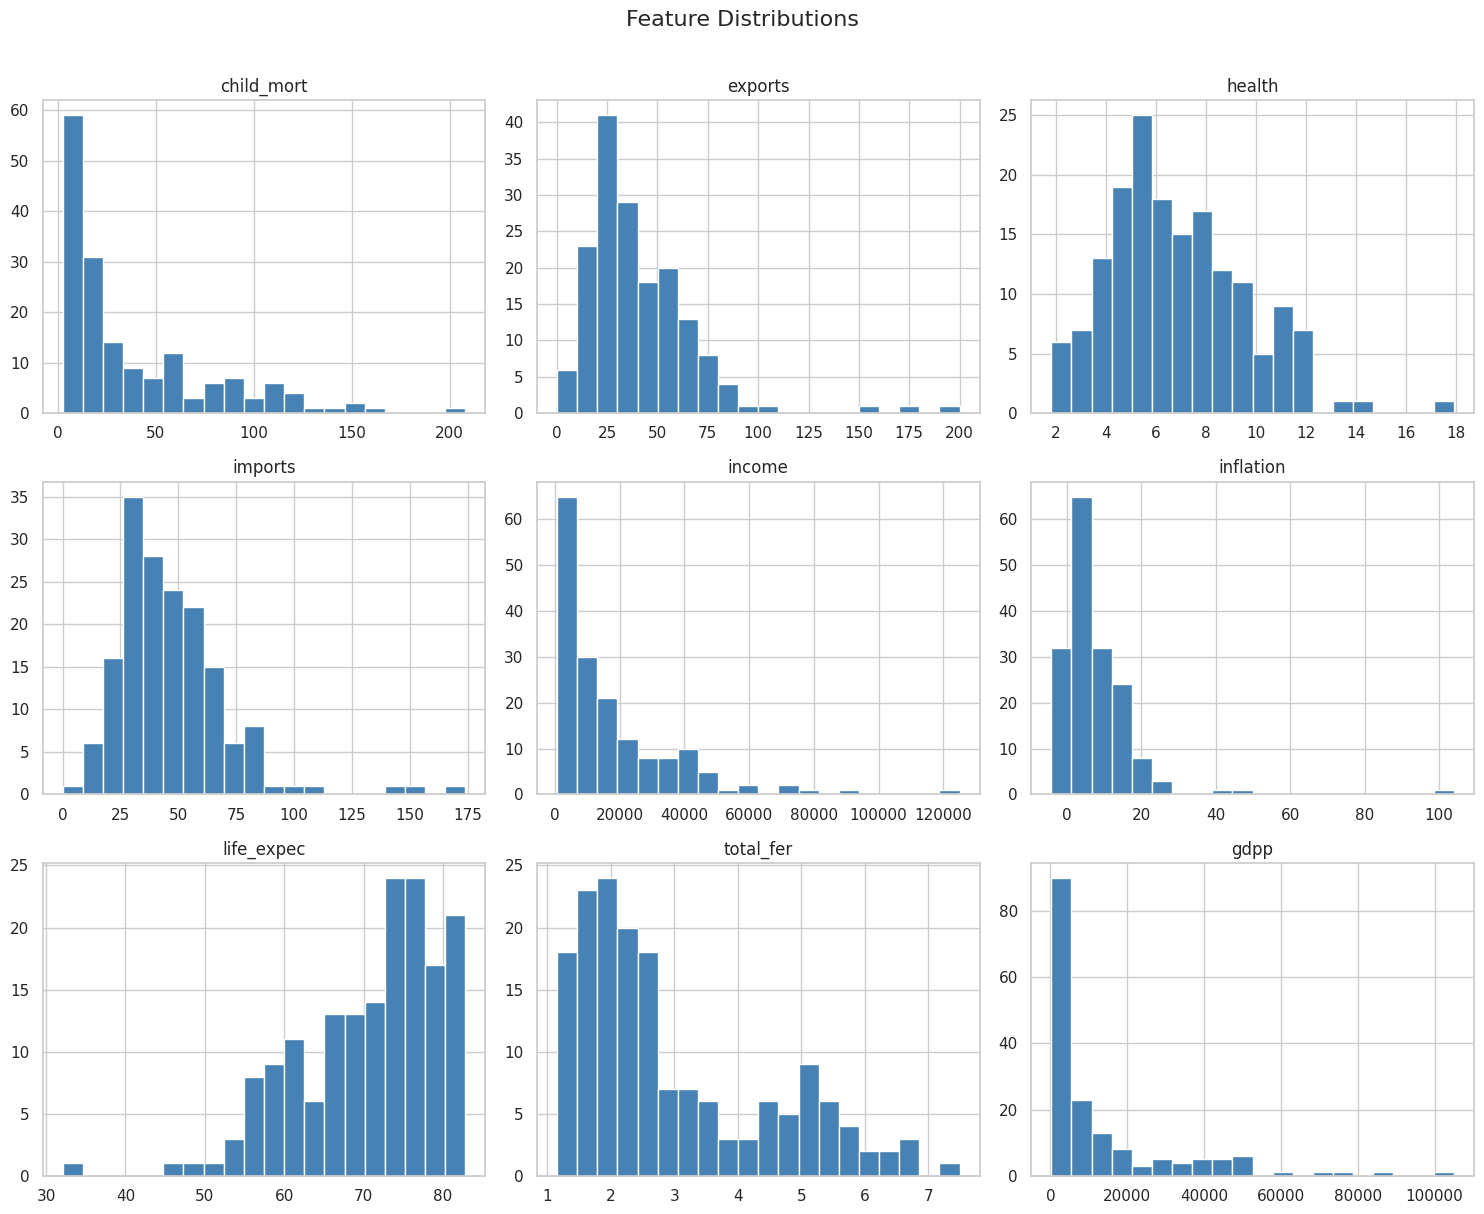

In [7]:
# Distribution plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

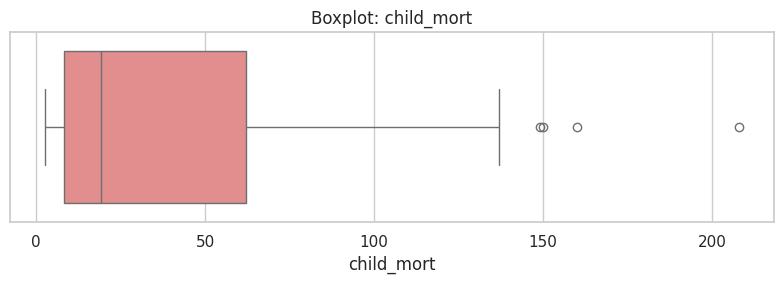

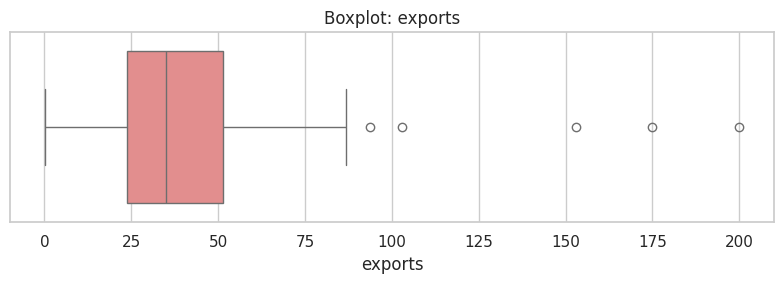

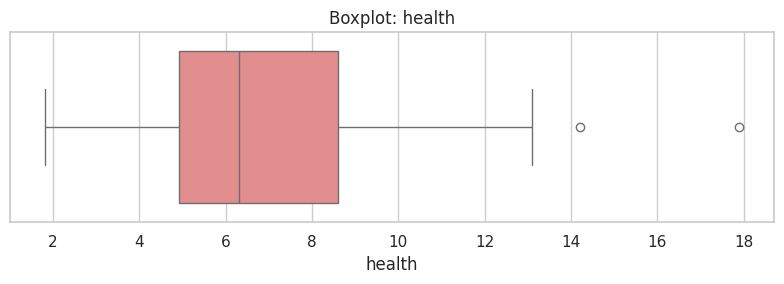

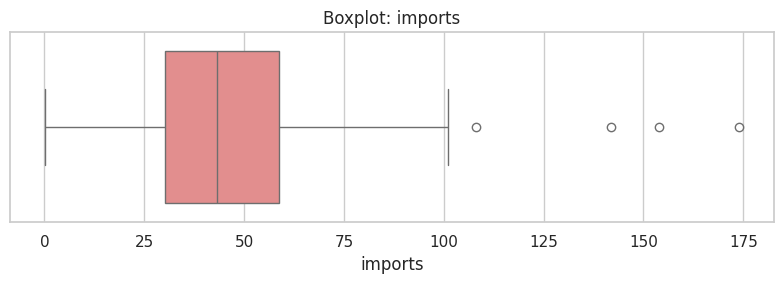

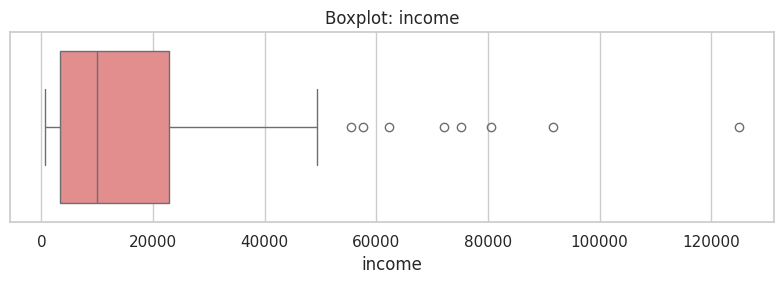

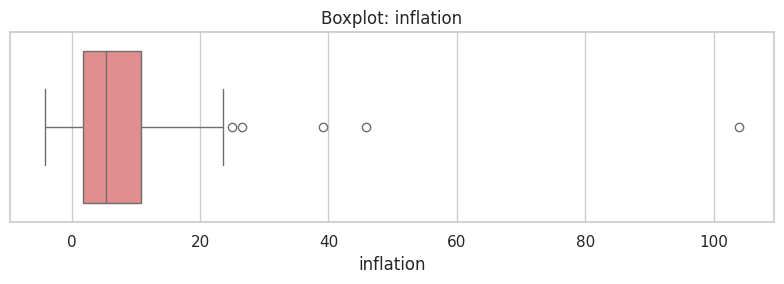

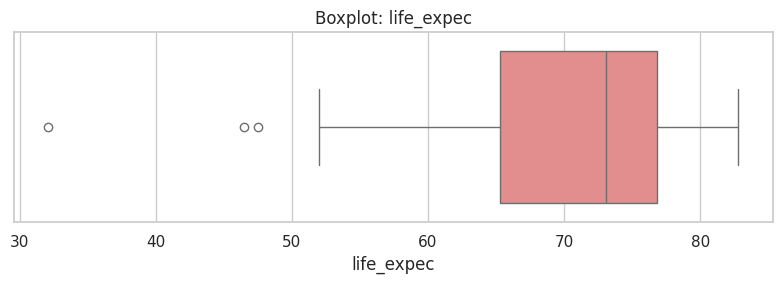

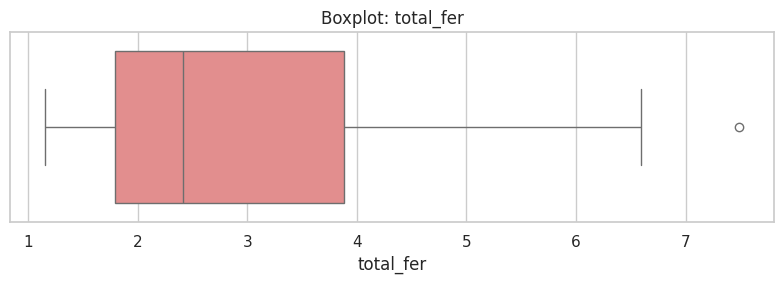

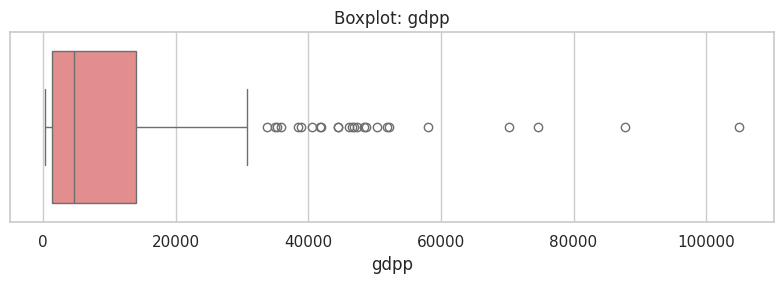

In [8]:
# Boxplots for outlier detection
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()

## 7) Feature Scaling

Clustering algorithms are distance-based, so all features must be on the same scale. We use `StandardScaler`.

In [9]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print("Mean ≈ 0:", np.allclose(X_scaled.mean(axis=0), 0, atol=1e-10))
print("Std  ≈ 1:", np.allclose(X_scaled.std(axis=0), 1, atol=1e-10))

Scaled feature matrix shape: (167, 9)
Mean ≈ 0: True
Std  ≈ 1: True


## 8) K-Means: Elbow Method

We test k ∈ [2, 10] and plot the inertia curve. The "elbow" point suggests the optimal number of clusters.

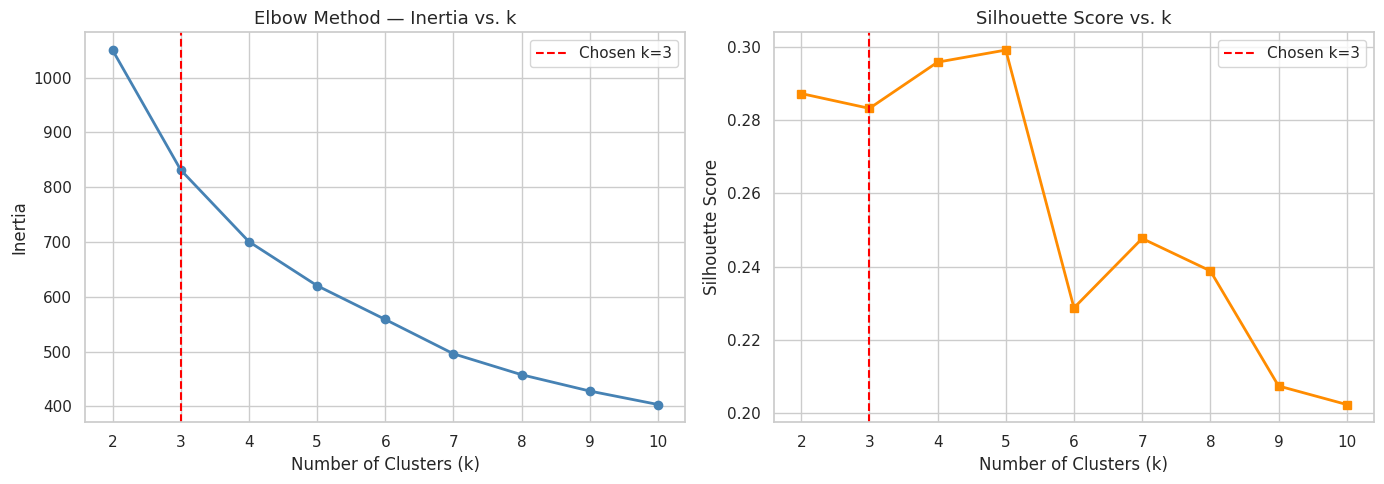


Silhouette scores per k:
  k=2: 0.2874
  k=3: 0.2833
  k=4: 0.2960
  k=5: 0.2993
  k=6: 0.2287
  k=7: 0.2477
  k=8: 0.2388
  k=9: 0.2073
  k=10: 0.2022


In [10]:
inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs. k', fontsize=13)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=3, color='red', linestyle='--', label='Chosen k=3')
axes[0].legend()

axes[1].plot(list(k_values), sil_scores, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score vs. k', fontsize=13)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=3, color='red', linestyle='--', label='Chosen k=3')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nSilhouette scores per k:")
for k, s in zip(k_values, sil_scores):
    print(f"  k={k}: {s:.4f}")

## 9) Train K-Means with Best k

Based on the elbow plot, **k = 3** provides a good balance between compactness and interpretability, aligning with three natural socio-economic tiers: developed, developing, and underdeveloped nations.

In [11]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"Silhouette Score (k={best_k}): {score:.4f}")
print(f"\nCluster sizes:")
print(df['kmeans_cluster'].value_counts().sort_index())

if 'country' in df.columns:
    display(df[['country', 'kmeans_cluster']].head(10))

Silhouette Score (k=3): 0.2833

Cluster sizes:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2
5,Argentina,2
6,Armenia,2
7,Australia,0
8,Austria,0
9,Azerbaijan,2


## 10) DBSCAN (Secondary Clustering Method)

DBSCAN finds clusters of arbitrary shape and marks outlier countries as noise (label = -1). Parameters: `eps=1.5`, `min_samples=5`.

In [12]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

counts = df['dbscan_cluster'].value_counts().sort_index()
print("DBSCAN Cluster Distribution:")
print(counts)
print(f"\nNoise points (label=-1): {(df['dbscan_cluster'] == -1).sum()}")

if 'country' in df.columns:
    noise_countries = df[df['dbscan_cluster'] == -1]['country'].tolist()
    print(f"\nCountries flagged as outliers/noise:")
    print(noise_countries)

DBSCAN Cluster Distribution:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Noise points (label=-1): 30

Countries flagged as outliers/noise:
['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'South Africa', 'Timor-Leste', 'Turkmenistan', 'United States', 'Venezuela']


## 11) PCA Visualization

We reduce the 9-dimensional scaled data to 2 principal components and plot K-Means cluster assignments.

Explained variance by PC1: 45.95%
Explained variance by PC2: 17.18%
Total variance captured: 63.13%


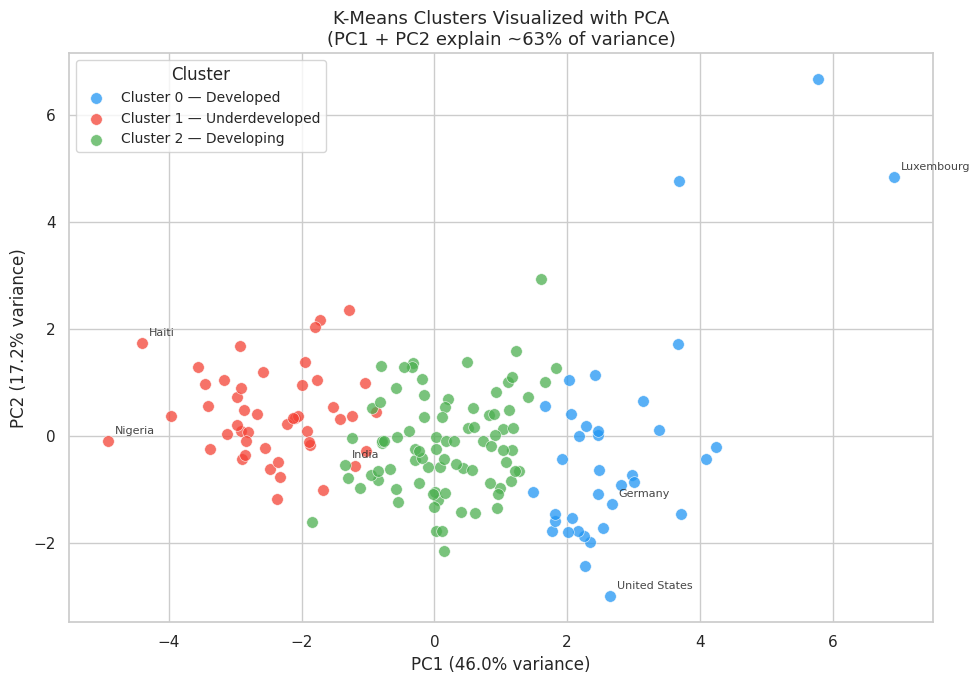

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Explained variance by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance captured: {sum(pca.explained_variance_ratio_):.2%}")

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster'].astype(str)
})

plt.figure(figsize=(10, 7))
palette = {'0': '#2196F3', '1': '#F44336', '2': '#4CAF50'}
cluster_labels = {'0': 'Cluster 0 — Developed', '1': 'Cluster 1 — Underdeveloped', '2': 'Cluster 2 — Developing'}

for c, grp in viz.groupby('cluster'):
    plt.scatter(grp['pca1'], grp['pca2'], label=cluster_labels[c],
                c=palette[c], alpha=0.75, s=70, edgecolors='white', linewidth=0.5)

if 'country' in df.columns:
    highlight = ['Haiti', 'Luxembourg', 'United States', 'India', 'Nigeria', 'Germany']
    for idx, row in df.iterrows():
        if row['country'] in highlight:
            loc = df.index.get_loc(idx)
            if loc < len(X_pca):
                plt.annotate(row['country'], (X_pca[loc, 0], X_pca[loc, 1]),
                             fontsize=8, alpha=0.85,
                             xytext=(5, 5), textcoords='offset points')

plt.title('K-Means Clusters Visualized with PCA\n(PC1 + PC2 explain ~63% of variance)', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster', fontsize=10)
plt.tight_layout()
plt.show()

## 12) Cluster Profiling

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster 0 — Developed,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
Cluster 1 — Underdeveloped,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
Cluster 2 — Developing,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


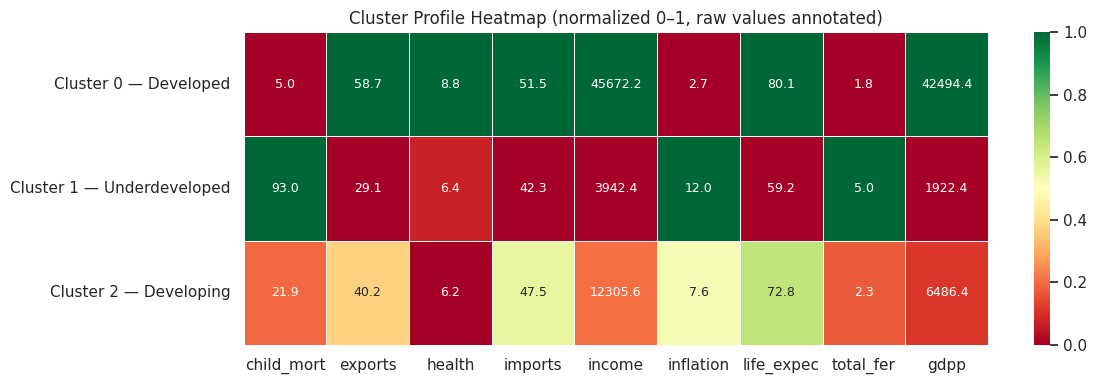


Cluster 0 — Developed (36 countries):
Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Portugal, Qatar, Singapore, Slovak Republic, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

Cluster 1 — Underdeveloped (47 countries):
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

Cluster 2 — Developing (84 countries):
Albania, Algeria, Antigua and Barbu

In [14]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = ['Cluster 0 — Developed', 'Cluster 1 — Underdeveloped', 'Cluster 2 — Developing']
display(profile)

# Heatmap of cluster profiles
plt.figure(figsize=(12, 4))
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Cluster Profile Heatmap (normalized 0–1, raw values annotated)', fontsize=12)
plt.tight_layout()
plt.show()

# Countries per cluster
for i, label in enumerate(['Developed', 'Underdeveloped', 'Developing']):
    countries = df[df['kmeans_cluster'] == i]['country'].sort_values().tolist()
    print(f"\nCluster {i} — {label} ({len(countries)} countries):")
    print(', '.join(countries))

## 13) Final Insights & Observations

Based on the K-Means clustering analysis (k=3), the following five observations summarize the socio-economic structure of the 167 countries:

---

### Cluster 0 — Developed Nations (36 countries)
Countries like **USA, Germany, Norway, Australia, Japan, Switzerland** fall here.  
- **Lowest child mortality** (avg ≈ 5.0 per 1000) and **highest life expectancy** (avg ≈ 80 years)
- **Highest income** (avg ≈ \$42,494) and **GDP per capita** (avg ≈ \$42,494)
- Strong investment in healthcare (avg health expenditure ≈ 8.81% of GDP)
- These nations do **not** require humanitarian aid — they are aid contributors.

---

### Cluster 1 — Underdeveloped Nations (47 countries)
Countries like **Afghanistan, Nigeria, Chad, Burkina Faso, Sierra Leone, Haiti** fall here.  
- **Highest child mortality** (avg ≈ 93 per 1000 births) — the most critical humanitarian concern
- **Lowest life expectancy** (avg ≈ 59 years) and **lowest GDP per capita** (avg ≈ \$1,922)
- High fertility rates (avg ≈ 5.01 children per woman) indicating high population growth and limited family planning
- **These countries should be the top priority for international aid and development programs.**

---

### Cluster 2 — Developing Nations (84 countries)
Countries like **India, Brazil, China, Mexico, Indonesia, Vietnam** fall here.  
- Moderate child mortality (avg ≈ 22) and life expectancy (avg ≈ 73 years)
- GDP per capita avg ≈ \$6,486 — significantly higher than Cluster 1 but far below Cluster 0
- This is the largest cluster (84 countries) — a diverse group ranging from emerging economies to lower-middle-income nations
- Targeted investment in healthcare and education could accelerate transitions to Cluster 0 status.

---

### Observation 4 — DBSCAN Identifies True Outliers
DBSCAN (eps=1.5, min_samples=5) labeled **30 countries as noise (outliers)**, including nations with extreme characteristics like:
- **Luxembourg, Qatar, Singapore** — extremely high income/GDP relative to neighbors
- **Haiti** — extreme child mortality (208 per 1000) and very low life expectancy (32 years), indicating a humanitarian crisis
- These outliers are not well-captured by K-Means' spherical clusters, making DBSCAN a valuable complementary method.

---

### Observation 5 — Key Drivers: Child Mortality & Income are Primary Separators
The PCA plot shows PC1 (capturing ~46% of variance) primarily separates clusters along the **development axis** — combining child mortality, income, and life expectancy signals.  
Countries requiring the most immediate aid (Cluster 1) are clearly separated in the lower-left quadrant, while developed nations (Cluster 0) cluster in the upper-right, confirming that **economic output and health outcomes are deeply interlinked.**

In [15]:
# Summary table
summary = pd.DataFrame({
    'Cluster': ['0 — Developed', '1 — Underdeveloped', '2 — Developing'],
    'Count': [df[df['kmeans_cluster']==i].shape[0] for i in range(3)],
    'Avg Child Mort': [df[df['kmeans_cluster']==i]['child_mort'].mean().round(1) for i in range(3)],
    'Avg Life Expec': [df[df['kmeans_cluster']==i]['life_expec'].mean().round(1) for i in range(3)],
    'Avg Income': [df[df['kmeans_cluster']==i]['income'].mean().round(0) for i in range(3)],
    'Avg GDPP': [df[df['kmeans_cluster']==i]['gdpp'].mean().round(0) for i in range(3)],
    'Aid Priority': ['None', 'HIGHEST', 'Medium']
})
display(summary)
print(f"\nFinal Silhouette Score: {silhouette_score(X_scaled, df['kmeans_cluster']):.4f}")
print("\nClustering pipeline complete!")

,Cluster,Count,Avg Child Mort,Avg Life Expec,Avg Income,Avg GDPP,Aid Priority
0,0 — Developed,36,5.0,80.1,45672.0,42494.0,None
1,1 — Underdeveloped,47,93.0,59.2,3942.0,1922.0,HIGHEST
2,2 — Developing,84,21.9,72.8,12306.0,6486.0,Medium



Final Silhouette Score: 0.2833

Clustering pipeline complete!
